In [34]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Processed Dataset(from Q1)

In [35]:
# Load the dataset
df = pd.read_csv('TaxiData.csv')

# Convert trip_start_timestamp to datetime
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'], unit='s')

# Ensure community areas are categorical
df['pickup_community_area'] = df['pickup_community_area'].astype('category')
df['dropoff_community_area'] = df['dropoff_community_area'].astype('category')

import warnings
warnings.filterwarnings("ignore")
# Impute numerical columns with mean
numerical_cols = ['fare', 'trip_miles', 'trip_seconds', 'tips']
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Impute categorical columns with mode or label as 'Unknown'
categorical_cols = ['payment_type', 'company']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

# Drop rows with missing latitude/longitude data if they are critical
df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'], inplace=True)

## 3.a Fare and Tip Distribution

### Fare Distribution by the hour of the day

    trip_start_hour   min     max       mean  median        std
0                 0  0.01   66.65  10.444878   8.150   7.514267
1                 1  0.00   48.25   9.796603   8.050   6.031530
2                 2  0.00   87.65   9.544559   7.750   7.166220
3                 3  3.25   44.05   8.969930   7.650   4.900257
4                 4  0.00   48.05  10.355625   7.850   7.733013
5                 5  3.25   43.25  17.078273  11.850  12.593411
6                 6  0.00   57.05  16.235220   9.475  12.692483
7                 7  3.25  175.05  13.298789   8.250  14.118788
8                 8  0.00  700.07  13.176564   7.700  31.931618
9                 9  0.00   57.25  10.532022   7.650   8.264682
10               10  0.00   75.65  11.578606   7.450  10.203808
11               11  0.00   58.65  11.867844   7.650  10.579237
12               12  3.25   58.75  11.054751   7.250   9.581680
13               13  0.00   61.25  12.081994   7.650  10.322304
14               14  0.01   88.05  11.70

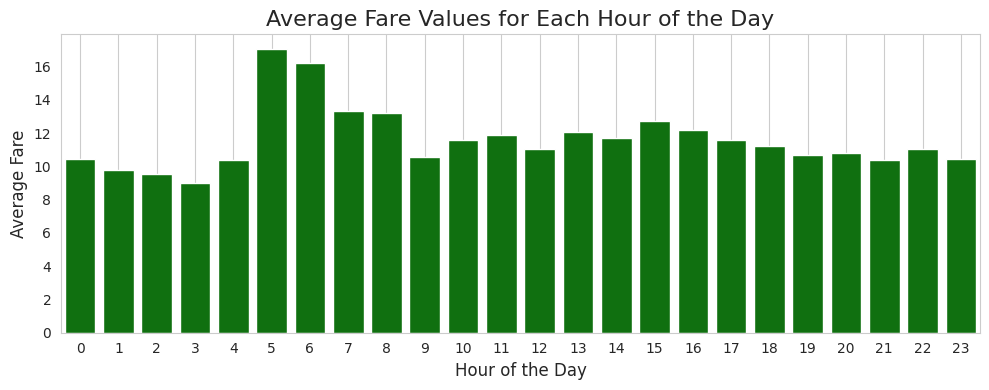

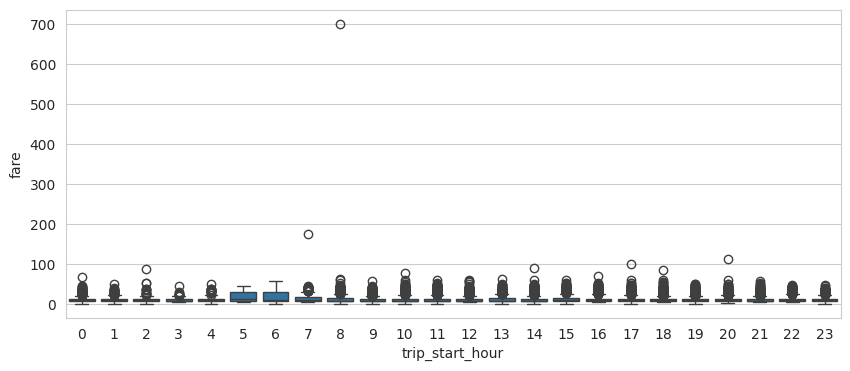

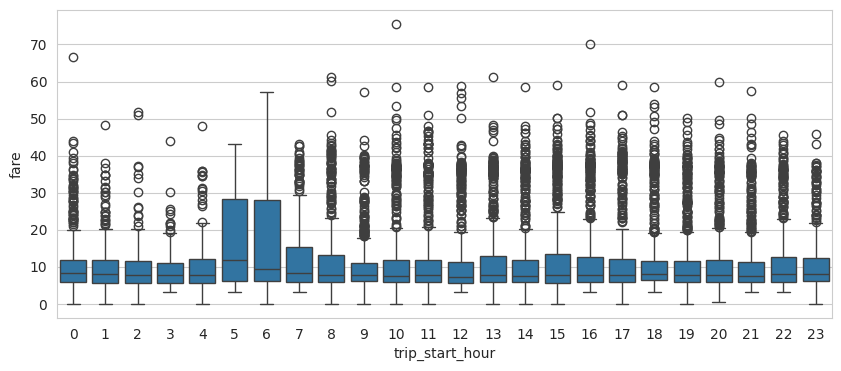

In [36]:

# Extract time-related features if not already in the dataset
df['trip_start_hour'] = df['trip_start_timestamp'].dt.hour
df['trip_start_day'] = df['trip_start_timestamp'].dt.day_name()
df['trip_start_month'] = df['trip_start_timestamp'].dt.month_name()

# Set plot style for better aesthetics
sns.set_style("whitegrid")




# Print analysis of fare for each hour
fare_stats_per_hour = df.groupby('trip_start_hour')['fare'].agg(['min', 'max', 'mean', 'median', 'std']).reset_index()
print(fare_stats_per_hour)


# Calculate average fare for each hour
avg_fare_per_hour = df.groupby('trip_start_hour')['fare'].mean().reset_index()

# Plotting
plt.figure(figsize=(10,4))
sns.barplot(data=avg_fare_per_hour, x='trip_start_hour', y='fare', color='green')
plt.title('Average Fare Values for Each Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Fare', fontsize=12)
plt.xticks(range(24))  # Show all hours
plt.grid()

plt.tight_layout()
plt.show()

# box plot for fares vs trip_start_hour
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='trip_start_hour', y='fare')

# Remove outliers based on fare
Q1 = df['fare'].quantile(0.05)
Q3 = df['fare'].quantile(0.95)
IQR = Q3 - Q1
df_no_outliers = df[~((df['fare'] < (Q1 - 1.5 * IQR)) | (df['fare'] > (Q3 + 1.5 * IQR)))]

# Plot the boxplot again without outliers
plt.figure(figsize=(10,4))
sns.boxplot(data=df_no_outliers, x='trip_start_hour', y='fare')
plt.show()


```
Analysis:
1. Fare Patterns by Hour of Day

High Fare Hours: We can observe that the fares are notably higher around 5-7 AM. This could be due to higher demand during early morning hours.

Low Fare Hours: Fares tend to be lower between 2-4 AM and later in the day around 19-23 hours. During these times, the fare mean is relatively stable compared to the morning hours.

Variance and Outliers: The box plot has great number of outliers throughout the whole day. The most extreme being at 7-8 am. These outliers could indicate longer trips leading to usually high fare. While other outliers throught the day are due to increased demand during peak travel times leading to higher fares or increased number of people travelling longer distances leading to more number of outliers.

2. Clusters

Cluster of High Fares: Between 5-7 AM indicating that there is a cluster of higher fares.

Cluster of Stable Fares: During midday (10-15 hours), the fares are more stable with fewer extreme outliers and lower variance compared to early morning and evening hours.
```

### Fare Distribution by day of the week

  trip_start_day   min     max       mean  median        std
0         Friday  0.00  700.07  11.627552    8.05  16.741590
1         Monday  0.00   84.25  11.944169    7.65  10.282861
2       Saturday  0.00  112.65  10.140442    7.85   7.742242
3         Sunday  0.32   59.75  11.454193    8.25   9.058606
4       Thursday  0.00   88.05  11.736768    7.85   9.878963
5        Tuesday  0.00   58.75  11.008483    7.45   9.231060
6      Wednesday  0.00  175.05  11.501094    7.65  10.424406


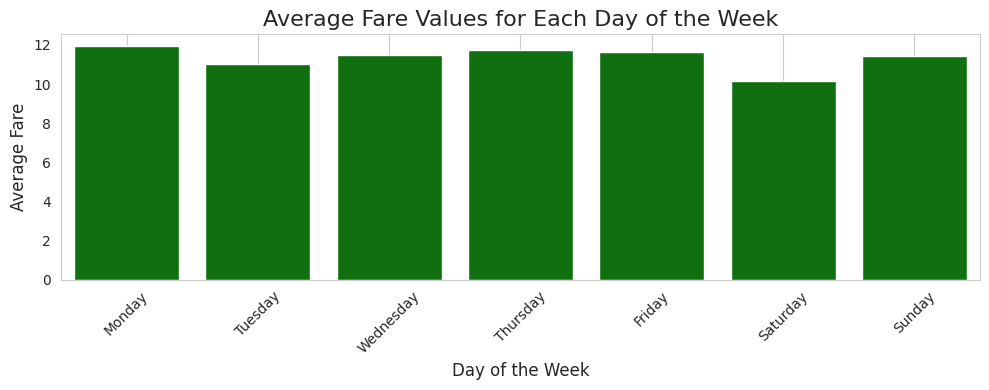

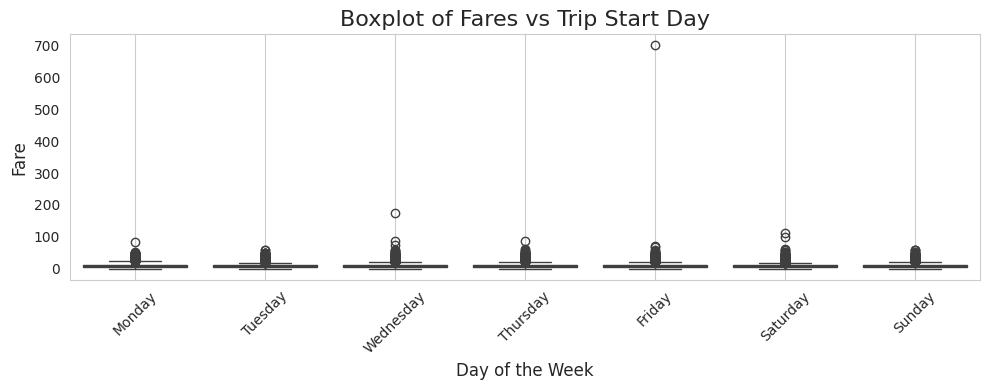

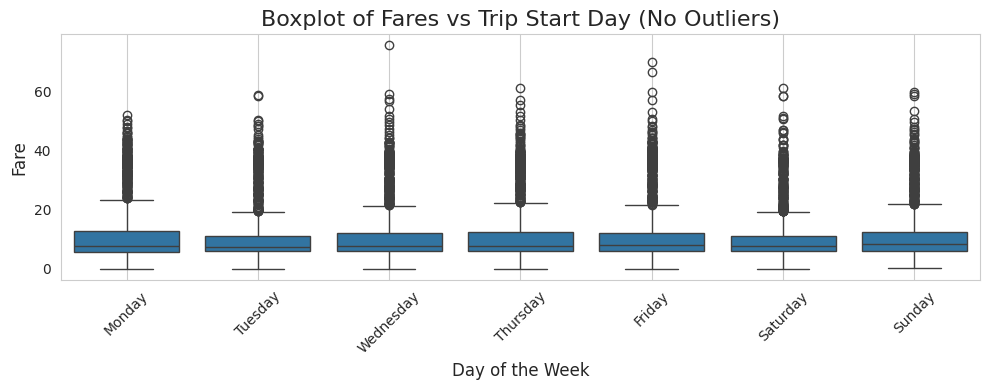

In [37]:
# Calculate average fare for each day of the week
avg_fare_per_day = df.groupby('trip_start_day')['fare'].mean().reset_index()

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Print analysis of fare for each day
fare_stats_per_day = df.groupby('trip_start_day')['fare'].agg(['min', 'max', 'mean', 'median', 'std']).reset_index()
print(fare_stats_per_day)

# Plotting
plt.figure(figsize=(10,4))
sns.barplot(data=avg_fare_per_day, x='trip_start_day', y='fare', color='green', order=order)
plt.title('Average Fare Values for Each Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Fare', fontsize=12)
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()

# Boxplot for fares vs trip_start_day
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='trip_start_day', y='fare', order=order)
plt.title('Boxplot of Fares vs Trip Start Day', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# Plot the boxplot again without outliers
plt.figure(figsize=(10,4))
sns.boxplot(data=df_no_outliers, x='trip_start_day', y='fare', order=order)
plt.title('Boxplot of Fares vs Trip Start Day (No Outliers)', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()


```
Analysis:
1. Fare Patterns by day of week

Variance and Outliers: The box plot has great number of outliers throughout the whole day. The most extreme being at 7-8 am. These outliers could indicate longer trips leading to usually high fare. While other outliers throught the day are due to increased demand during peak travel times leading to higher fares or increased number of people travelling longer distances leading to more number of outliers.

2. Clusters

Weekdays together are consistent with the fare while during the weekends we can observe a drop in the average fare amount, possibly due to weekend rest of workers.

``` 

### Tips Distribution by the hour of the day

    trip_start_hour  min    max      mean  median       std
0                 0  0.0   8.80  0.892083     0.0  1.619139
1                 1  0.0  10.00  0.931536     0.0  1.542027
2                 2  0.0  10.35  0.775760     0.0  1.509854
3                 3  0.0   5.80  0.774175     0.0  1.296404
4                 4  0.0  15.00  0.722135     0.0  1.804518
5                 5  0.0  10.00  1.686259     0.0  2.630527
6                 6  0.0  10.06  1.224615     0.0  2.544496
7                 7  0.0  26.55  1.132837     0.0  2.586093
8                 8  0.0  13.85  1.176274     0.0  2.235365
9                 9  0.0  15.00  0.964275     0.0  1.864312
10               10  0.0  11.45  1.057909     0.0  2.112656
11               11  0.0  10.85  1.034179     0.0  2.076549
12               12  0.0  13.45  0.949751     0.0  1.900705
13               13  0.0  12.56  1.104003     0.0  2.137075
14               14  0.0  11.55  1.088189     0.0  2.038556
15               15  0.0  15.00  1.09768

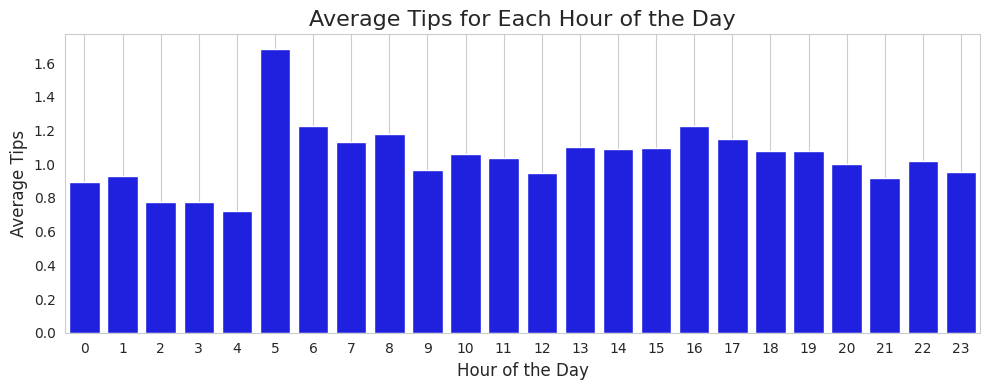

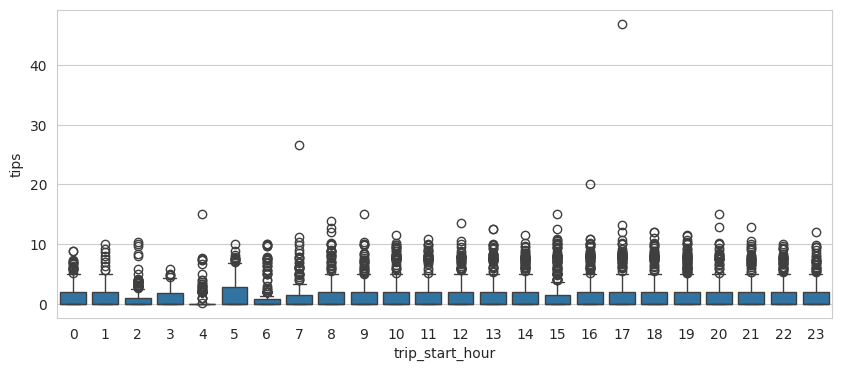

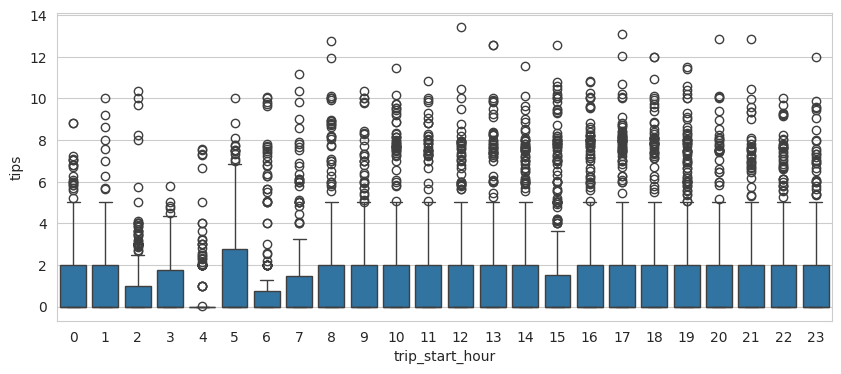

In [38]:
# Print analysis of tips for each hour
tips_stats_per_hour = df.groupby('trip_start_hour')['tips'].agg(['min', 'max', 'mean', 'median', 'std']).reset_index()
print(tips_stats_per_hour)

# Calculate average tips for each hour
avg_tips_per_hour = df.groupby('trip_start_hour')['tips'].mean().reset_index()

# Plotting
plt.figure(figsize=(10,4))
sns.barplot(data=avg_tips_per_hour, x='trip_start_hour', y='tips', color='blue')
plt.title('Average Tips for Each Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Tips', fontsize=12)
plt.xticks(range(24))  # Show all hours
plt.grid()

plt.tight_layout()
plt.show()

# Box plot for tips vs trip_start_hour
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='trip_start_hour', y='tips')

# Remove outliers based on tips
Q1_tips = df['tips'].quantile(0.05)
Q3_tips = df['tips'].quantile(0.95)
IQR_tips = Q3_tips - Q1_tips
df_no_outliers_tips = df[~((df['tips'] < (Q1_tips - 1.5 * IQR_tips)) | (df['tips'] > (Q3_tips + 1.5 * IQR_tips)))]

# Plot the boxplot again without outliers
plt.figure(figsize=(10,4))
sns.boxplot(data=df_no_outliers_tips, x='trip_start_hour', y='tips')
plt.show()


```
Analysis:
1. Fare Patterns by Hour of Day

High Fare Hours: We can observe that the fares are notably higher around 5-7 AM. This could be due to higher demand during early morning hours.

Low Fare Hours: Fares tend to be lower between 2-4 AM and later in the day around 19-23 hours. During these times, the fare mean is relatively stable compared to the morning hours.

Variance and Outliers: The box plot has great number of outliers throughout the whole day. The most extreme being at 7-8 am. These outliers could indicate longer trips leading to usually high fare. While other outliers throught the day are due to increased demand during peak travel times leading to higher fares or increased number of people travelling longer distances leading to more number of outliers.

2. Clusters

Cluster of High Fares: Between 5-7 AM indicating that there is a cluster of higher fares.

Cluster of Stable Fares: During midday (10-15 hours), the fares are more stable with fewer extreme outliers and lower variance compared to early morning and evening hours.
```

### Tips Distribution by day of the week

  trip_start_day  min    max      mean  median       std
0         Friday  0.0  15.00  1.007345     0.0  1.996127
1         Monday  0.0  20.00  1.116852     0.0  2.113275
2       Saturday  0.0  15.00  0.763092     0.0  1.564798
3         Sunday  0.0  13.11  0.991526     0.0  1.942217
4       Thursday  0.0  47.00  1.204850     0.0  2.447037
5        Tuesday  0.0  12.56  1.105209     0.0  2.062985
6      Wednesday  0.0  12.85  1.115989     0.0  2.020862


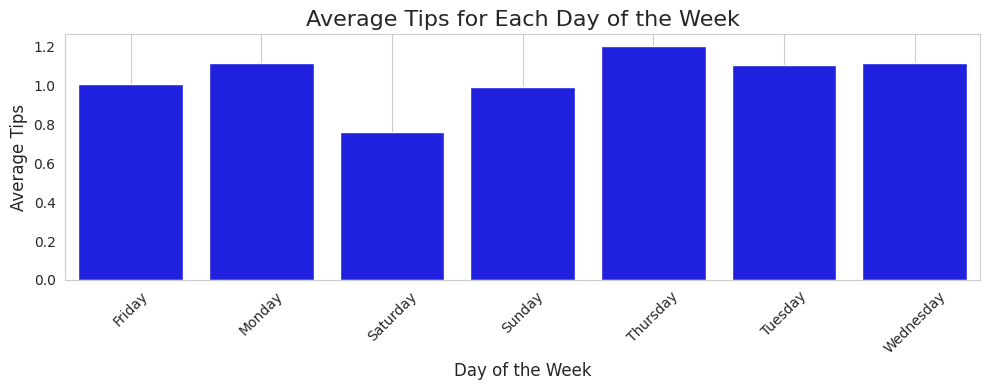

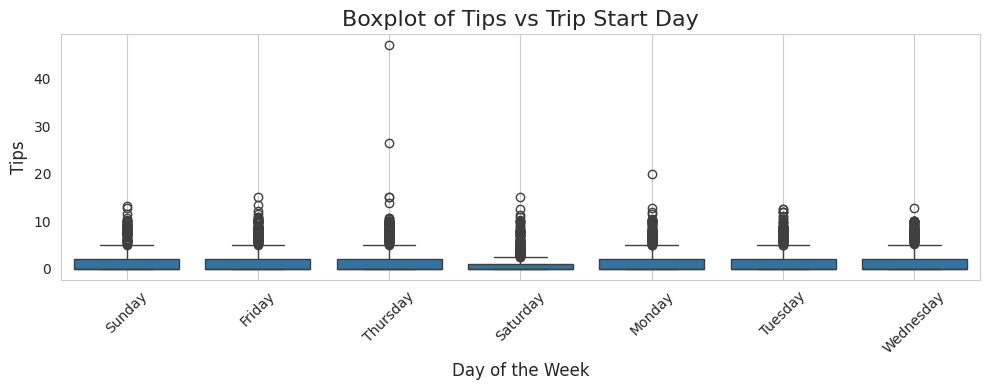

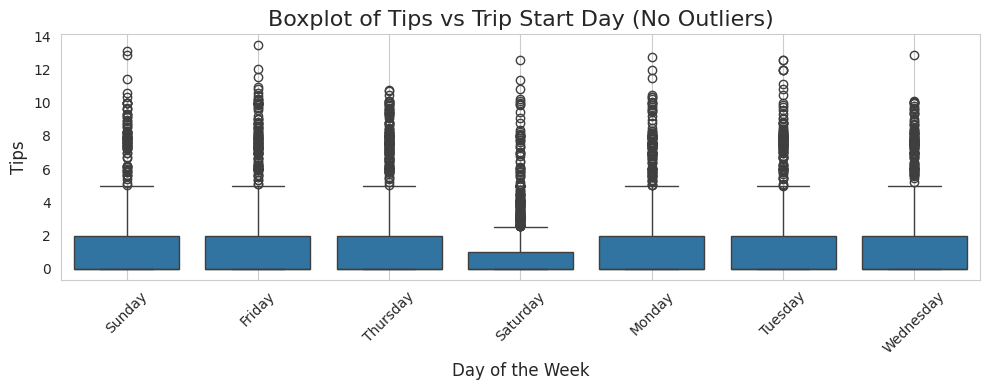

In [39]:
# Calculate average tips for each day of the week
avg_tips_per_day = df.groupby('trip_start_day')['tips'].mean().reset_index()

# Print analysis of tips for each day
tips_stats_per_day = df.groupby('trip_start_day')['tips'].agg(['min', 'max', 'mean', 'median', 'std']).reset_index()
print(tips_stats_per_day)

# Plotting
plt.figure(figsize=(10,4))
sns.barplot(data=avg_tips_per_day, x='trip_start_day', y='tips', color='blue')
plt.title('Average Tips for Each Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Tips', fontsize=12)
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()

# Boxplot for tips vs trip_start_day
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='trip_start_day', y='tips')
plt.title('Boxplot of Tips vs Trip Start Day', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Tips', fontsize=12)
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()

# Plot the boxplot again without outliers
plt.figure(figsize=(10,4))
sns.boxplot(data=df_no_outliers_tips, x='trip_start_day', y='tips')
plt.title('Boxplot of Tips vs Trip Start Day (No Outliers)', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Tips', fontsize=12)
plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()


```
Analysis:
1. Fare Patterns by Hour of Day

High Fare Hours: We can observe that the fares are notably higher around 5-7 AM. This could be due to higher demand during early morning hours.

Low Fare Hours: Fares tend to be lower between 2-4 AM and later in the day around 19-23 hours. During these times, the fare mean is relatively stable compared to the morning hours.

Variance and Outliers: The box plot has great number of outliers throughout the whole day. The most extreme being at 7-8 am. These outliers could indicate longer trips leading to usually high fare. While other outliers throught the day are due to increased demand during peak travel times leading to higher fares or increased number of people travelling longer distances leading to more number of outliers.

2. Clusters

Cluster of High Fares: Between 5-7 AM indicating that there is a cluster of higher fares.

Cluster of Stable Fares: During midday (10-15 hours), the fares are more stable with fewer extreme outliers and lower variance compared to early morning and evening hours.
```

## 3.b Payment method insights

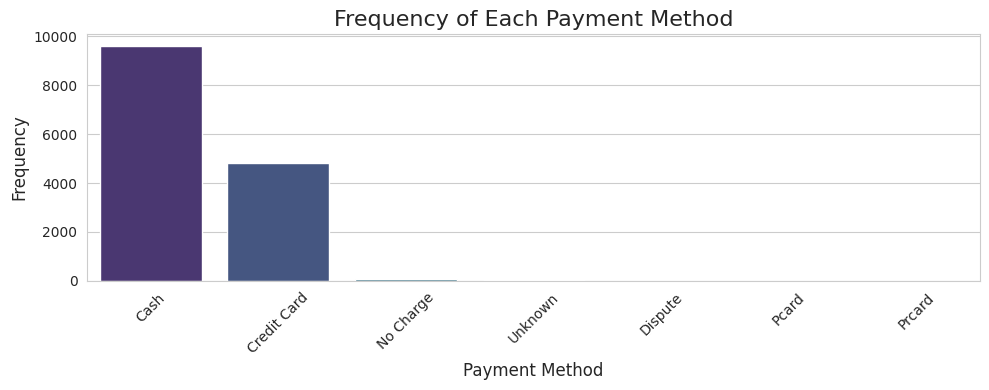

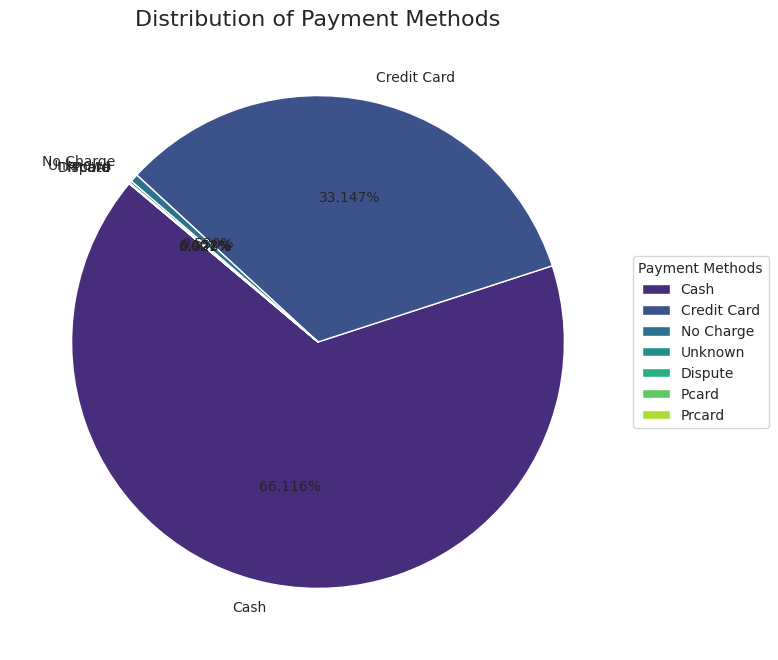

In [40]:
# Count the frequency of each payment method
payment_counts = df['payment_type'].value_counts()

# Bar chart
plt.figure(figsize=(10,4))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')
plt.title('Frequency of Each Payment Method', fontsize=16)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.3f%%', startangle=140, colors=sns.color_palette('viridis', len(payment_counts)))
plt.title('Distribution of Payment Methods', fontsize=16)
plt.legend(payment_counts.index, title="Payment Methods", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

```
Implications:
```

## 3.c Tips by Payment Method

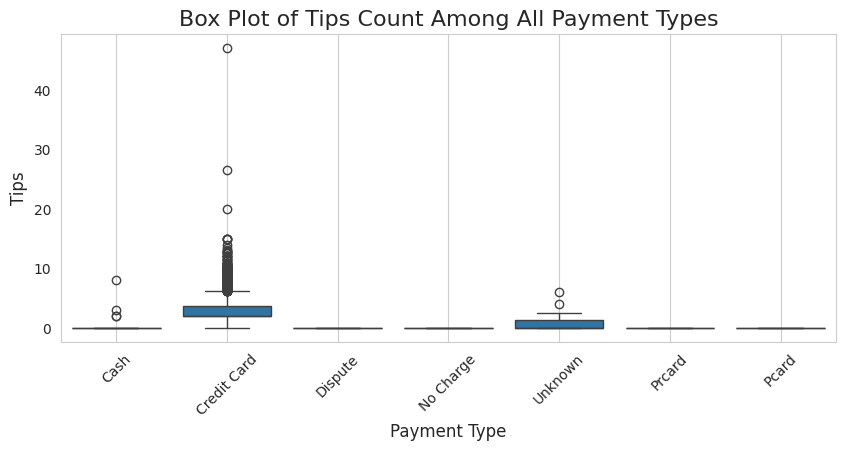

  payment_type      tips
0         Cash  0.001568
1  Credit Card  3.116804
2      Dispute  0.000000
3    No Charge  0.000000
4        Pcard  0.000000
5       Prcard  0.000000
6      Unknown  0.903182


In [41]:
# Box plot of tips count among all payment types
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='payment_type', y='tips')
plt.title('Box Plot of Tips Count Among All Payment Types', fontsize=16)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Tips', fontsize=12)
plt.xticks(rotation=45) # x axis label
plt.grid()
plt.show()

# Calculate average tips for each payment type
avg_tips_per_payment = df.groupby('payment_type')['tips'].mean().reset_index()

# Print the average tips
print(avg_tips_per_payment)


```
Interpretation:
```

###  3.d Fare vs. Distance

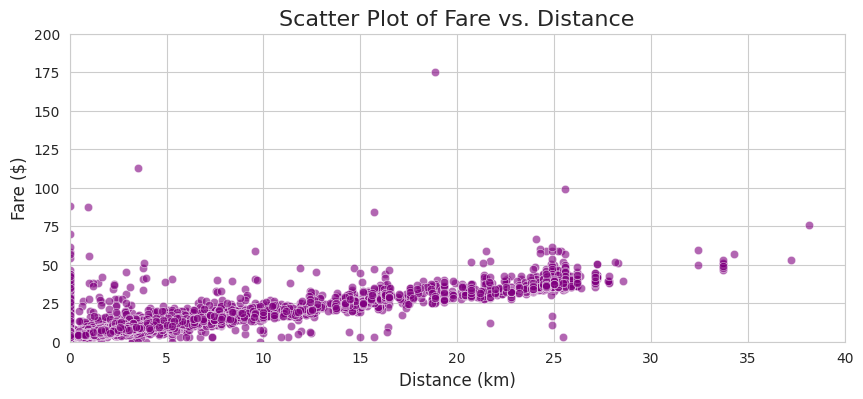

In [42]:
# Scatter plot for trip duration vs. trip distance

# Calculate distance using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of the Earth in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# Apply the haversine function to calculate distance
df['calculated_distance'] = df.apply(lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'], row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

plt.figure(figsize=(10,4))
sns.scatterplot(x='calculated_distance', y='fare', data=df, alpha=0.6, color='purple')
plt.title('Scatter Plot of Fare vs. Distance', fontsize=16)
plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.xlim(0,40)
plt.ylim(0,200)
plt.show()



In [43]:
# Calculate the mean of the columns
mean_x = df['calculated_distance'].mean()
mean_y = df['fare'].mean()

# Calculate the numerator and denominator for the correlation coefficient
numerator = np.sum((df['calculated_distance'] - mean_x) * (df['fare'] - mean_y))
denominator = np.sqrt(np.sum((df['calculated_distance'] - mean_x)**2) * np.sum((df['fare'] - mean_y)**2))

# Calculate the correlation coefficient
correlation_coefficient_manual = numerator / denominator

# Print the correlation coefficient
print(f'Correlation Coefficient: {correlation_coefficient_manual}')


Correlation Coefficient: 0.05424040839795119


```
Interpretation:
```